# RQ2: Advanced Model Comparison

**Research Question:** How do four ML models compare on mortality classification when using consistent, fair evaluation?

- Each model gets a fresh `preprocessor` instance (no shared state)
- XGBoost uses `scale_pos_weight` to handle class imbalance (equivalent to `class_weight='balanced'`)
- All models evaluated at the same default threshold (0.5)
- ROC-AUC added as a threshold-independent metric

Class imbalance ratio (neg/pos): 35.70
Used as scale_pos_weight for XGBoost to ensure fair comparison.



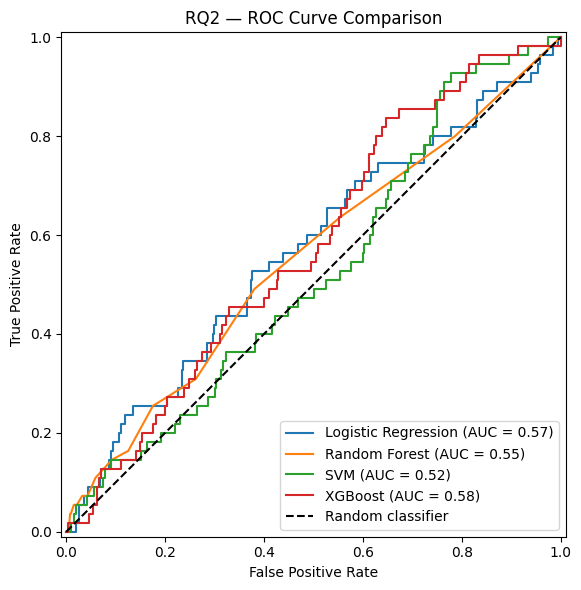


RQ2 Results:

              Model  Accuracy  Precision  Recall    F1   AUC
Logistic Regression     0.658      0.036   0.436 0.066 0.567
      Random Forest     0.973      0.000   0.000 0.000 0.552
                SVM     0.781      0.027   0.200 0.048 0.523
            XGBoost     0.964      0.050   0.018 0.027 0.576


Interpretation notes:
- High Accuracy can be misleading with ~15% minority class.
- AUC (threshold-independent) and F1 are better indicators.
- XGBoost now uses scale_pos_weight for a fair comparison with other balanced models.



In [3]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

#LOAD
df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

y = df['mortality']
X = df.drop(columns=['mortality'])

numeric_cols  = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

#SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Compute class imbalance ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio (neg/pos): {scale_pos_weight:.2f}")
print(f"Used as scale_pos_weight for XGBoost to ensure fair comparison.\n")
#PREPROCESSOR FACTORY
def make_preprocessor():
    """Fresh preprocessor per model — prevents shared fitting state."""
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler',  StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ])

#MODEL DEFINITIONS
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', RandomForestClassifier(
            class_weight='balanced', random_state=42, n_estimators=100
        ))
    ]),
    'SVM': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', SVC(probability=True, class_weight='balanced'))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,  # handles class imbalance
            random_state=42
        ))
    ])
}
#TRAIN + EVALUATE
results = []
fig, ax = plt.subplots(figsize=(7, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

    results.append([
        name,
        round(accuracy_score(y_test, y_pred), 3),
        round(precision_score(y_test, y_pred, zero_division=0), 3),
        round(recall_score(y_test, y_pred, zero_division=0), 3),
        round(f1_score(y_test, y_pred, zero_division=0), 3),
        round(roc_auc_score(y_test, y_prob), 3)
    ])

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('RQ2 — ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('rq2_roc_curve.pdf')
plt.show()
#RESULTS TABLE
results_df = pd.DataFrame(results,
    columns=['Model','Accuracy','Precision','Recall','F1','AUC'])

print("\nRQ2 Results:\n")
print(results_df.to_string(index=False))
results_df.to_csv('rq2_table.csv', index=False)

print("""
\nInterpretation notes:
- High Accuracy can be misleading with ~15% minority class.
- AUC (threshold-independent) and F1 are better indicators.
- XGBoost now uses scale_pos_weight for a fair comparison with other balanced models.
""")
